In [ ]:
!pip -q install 'huggingface_hub==0.26.2' hf_transfer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.5/447.5 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 97.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.26.2 which is incompatible.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.26.2 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.26.2 which is incompatible.


In [ ]:
import os
from google.colab import userdata

hf_read_token = userdata.get('HF_TOKEN')

if hf_read_token is None:
    raise ValueError('Secret HF_READ_TOKEN is not found. Add it in Colab Secrets and enable notebook access.')

os.environ['HF_TOKEN'] = hf_read_token

In [ ]:
from pathlib import Path
from huggingface_hub import hf_hub_download

project_dir = Path('/content/fnspid_project')
raw_dir = project_dir / 'fnspid_raw'

raw_dir.mkdir(parents=True, exist_ok=True)

repo_id = 'Zihan1004/FNSPID'
repo_type = 'dataset'
filename = 'Stock_news/nasdaq_exteral_data.csv'

nasdaq_external_path = hf_hub_download(
    repo_id=repo_id,
    repo_type=repo_type,
    filename=filename,
    local_dir=str(raw_dir),
    token=hf_read_token,
    force_download=False
)

nasdaq_external_path = Path(nasdaq_external_path)

print('nasdaq_external_path:', nasdaq_external_path)

nasdaq_exteral_data.csv:   0%|          | 0.00/23.2G [00:00<?, ?B/s]

nasdaq_external_path: /content/fnspid_project/fnspid_raw/Stock_news/nasdaq_exteral_data.csv


## Работа с S&P500

In [ ]:
!pip -q install pandas_market_calendars lxml tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.0/131.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.3/213.3 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 7.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from tqdm.auto import tqdm
import pandas_market_calendars as mcal

project_dir = Path('/content/fnspid_project')
raw_dir = project_dir / 'fnspid_raw'

try:
    news_path = Path(nasdaq_external_path)
except NameError:
    news_path = raw_dir / 'Stock_news' / 'nasdaq_exteral_data.csv'

print('news_path:', news_path)

news_path: /content/fnspid_project/fnspid_raw/Stock_news/nasdaq_exteral_data.csv


In [ ]:
!pip -q install requests lxml

In [ ]:
import requests
from io import StringIO
import pandas as pd

sp500_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

headers = {
    'User-Agent': (
        'Mozilla/5.0 (X11; Linux x86_64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    )
}

response = requests.get(sp500_url, headers=headers, timeout=30)
response.raise_for_status()

tables = pd.read_html(StringIO(response.text))

print('n_tables:', len(tables))

sp500_raw = None

for table in tables:
    if {'Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry'}.issubset(table.columns):
        sp500_raw = table.copy()
        break

if sp500_raw is None:
    raise ValueError('S&P 500 constituents table was not found on the Wikipedia page.')

sp500_df = sp500_raw[
    ['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Date added']
].copy()

sp500_df.columns = [
    'ticker',
    'company_name',
    'gics_sector',
    'gics_sub_industry',
    'date_added'
]

sp500_df['ticker'] = sp500_df['ticker'].astype('string').str.upper().str.strip()
sp500_df['ticker_norm'] = sp500_df['ticker'].str.replace('-', '.', regex=False)

sp500_df['date_added'] = pd.to_datetime(sp500_df['date_added'], errors='coerce')

sp500_df = sp500_df.drop_duplicates('ticker_norm').reset_index(drop=True)

print('sp500_df shape:', sp500_df.shape)
display(sp500_df.head())

display(
    sp500_df
    .groupby('gics_sector', as_index=False)
    .agg(n_sp500_tickers=('ticker_norm', 'nunique'))
    .sort_values('n_sp500_tickers', ascending=False)
)

n_tables: 3
sp500_df shape: (503, 6)


,ticker,company_name,gics_sector,gics_sub_industry,date_added,ticker_norm
0,MMM,3M,Industrials,Industrial Conglomerates,1957-03-04,MMM
1,AOS,A. O. Smith,Industrials,Building Products,2017-07-26,AOS
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,1957-03-04,ABT
3,ABBV,AbbVie,Health Care,Biotechnology,2012-12-31,ABBV
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,2011-07-06,ACN


,gics_sector,n_sp500_tickers
6,Industrials,79
4,Financials,76
7,Information Technology,73
5,Health Care,58
1,Consumer Discretionary,48
2,Consumer Staples,36
10,Utilities,31
9,Real Estate,31
8,Materials,26
0,Communication Services,23


In [ ]:
start_date = '2009-01-01'
end_date = '2023-12-31'

weekend_policy = 'next_trading_day'

In [ ]:
nyse = mcal.get_calendar('NYSE')

schedule = nyse.schedule(
    start_date=start_date,
    end_date=end_date
)

trading_days = pd.DatetimeIndex(schedule.index).normalize()

print('n_trading_days:', len(trading_days))
print('first trading day:', trading_days.min())
print('last trading day:', trading_days.max())

n_trading_days: 3774
first trading day: 2009-01-02 00:00:00
last trading day: 2023-12-29 00:00:00


In [ ]:
all_calendar_days = pd.date_range(start_date, end_date, freq='D').normalize()

trading_arr = trading_days.values.astype('datetime64[ns]')
calendar_arr = all_calendar_days.values.astype('datetime64[ns]')

positions = np.searchsorted(trading_arr, calendar_arr, side='left')

aligned_trading_days = np.full(
    shape=len(all_calendar_days),
    fill_value=np.datetime64('NaT'),
    dtype='datetime64[ns]'
)

valid_positions = positions < len(trading_arr)
aligned_trading_days[valid_positions] = trading_arr[positions[valid_positions]]

date_to_trading_df = pd.DataFrame({
    'news_date': all_calendar_days,
    'trading_date': pd.to_datetime(aligned_trading_days)
})

date_to_trading_df = date_to_trading_df[
    date_to_trading_df['trading_date'].notna()
].copy()

date_to_trading_df = date_to_trading_df[
    date_to_trading_df['trading_date'] <= pd.Timestamp(end_date)
].copy()

date_to_trading_map = dict(
    zip(date_to_trading_df['news_date'], date_to_trading_df['trading_date'])
)

trading_days_set = set(trading_days)

display(date_to_trading_df.head())
display(date_to_trading_df.tail())

,news_date,trading_date
0,2009-01-01,2009-01-02
1,2009-01-02,2009-01-02
2,2009-01-03,2009-01-05
3,2009-01-04,2009-01-05
4,2009-01-05,2009-01-05


,news_date,trading_date
5471,2023-12-25,2023-12-26
5472,2023-12-26,2023-12-26
5473,2023-12-27,2023-12-27
5474,2023-12-28,2023-12-28
5475,2023-12-29,2023-12-29


In [ ]:
sample_df = pd.read_csv(news_path, nrows=5)

print('columns:')
print(sample_df.columns.tolist())

display(sample_df.head())

columns:
['Unnamed: 0', 'Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']


,Unnamed: 0,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,0.0,2023-12-16 23:00:00 UTC,Interesting A Put And Call Options For August ...,A,https://www.nasdaq.com/articles/interesting-a-...,NaN,NaN,"Investors in Agilent Technologies, Inc. (Symbo...",Because the $125.00 strike represents an appro...,The current analytical data (including greeks ...,Below is a chart showing the trailing twelve m...,"At Stock Options Channel, our YieldBoost formu..."
1,1.0,2023-12-12 00:00:00 UTC,Wolfe Research Initiates Coverage of Agilent T...,A,https://www.nasdaq.com/articles/wolfe-research...,NaN,NaN,"Fintel reports that on December 13, 2023, Wolf...","Fintel reports that on December 13, 2023, Wolf...","T. Rowe Price Investment Management holds 10,1...",Agilent Technologies Declares $0.24 Dividend O...,The projected annual revenue for Agilent Techn...
2,2.0,2023-12-12 00:00:00 UTC,Agilent Technologies Reaches Analyst Target Price,A,https://www.nasdaq.com/articles/agilent-techno...,NaN,NaN,"In recent trading, shares of Agilent Technolog...","In recent trading, shares of Agilent Technolog...","In recent trading, shares of Agilent Technolog...",When a stock reaches the target an analyst has...,When a stock reaches the target an analyst has...
3,3.0,2023-12-07 00:00:00 UTC,Agilent (A) Enhances BioTek Cytation C10 With ...,A,https://www.nasdaq.com/articles/agilent-a-enha...,NaN,NaN,Agilent Technologies A is enhancing its BioTek...,"Per a Grand View Research report, the global m...","Notably, Agilent enhanced the BioTek Cytation ...","Agilent Technologies, Inc. Price and Consensus...","Notably, Agilent enhanced the BioTek Cytation ..."
4,4.0,2023-12-07 00:00:00 UTC,"Pre-Market Most Active for Dec 7, 2023 : SQQQ,...",A,https://www.nasdaq.com/articles/pre-market-mos...,NaN,NaN,The NASDAQ 100 Pre-Market Indicator is up 70.2...,ProShares UltraPro Short QQQ (SQQQ) is -0.15 a...,"As reported by Zacks, the current mean recomme...","The total Pre-Market volume is currently 39,23...",The NASDAQ 100 Pre-Market Indicator is up 70.2...


In [ ]:
def pick_col(columns, candidates):
    lower_to_original = {col.lower(): col for col in columns}
    for candidate in candidates:
        if candidate.lower() in lower_to_original:
            return lower_to_original[candidate.lower()]
    return None

ticker_candidates = [
    'Stock_symbol',
    'stock_symbol',
    'stock_symbols',
    'ticker',
    'Ticker',
    'symbol',
    'Symbol',
    'Stock Symbol',
    'stock'
]

date_candidates = [
    'Date',
    'date',
    'datetime',
    'Datetime',
    'published_at',
    'publish_date',
    'Publish_date',
    'time',
    'Time'
]

ticker_col = pick_col(sample_df.columns, ticker_candidates)
date_col = pick_col(sample_df.columns, date_candidates)

if ticker_col is None:
    raise KeyError(f'Ticker column was not found. Available columns: {sample_df.columns.tolist()}')

if date_col is None:
    raise KeyError(f'Date column was not found. Available columns: {sample_df.columns.tolist()}')

print('ticker_col:', ticker_col)
print('date_col:', date_col)

display(sample_df[[date_col, ticker_col]].head())

ticker_col: Stock_symbol
date_col: Date


,Date,Stock_symbol
0,2023-12-16 23:00:00 UTC,A
1,2023-12-12 00:00:00 UTC,A
2,2023-12-12 00:00:00 UTC,A
3,2023-12-07 00:00:00 UTC,A
4,2023-12-07 00:00:00 UTC,A


In [ ]:
def pick_col(columns, candidates):
    lower_to_original = {col.lower(): col for col in columns}
    for candidate in candidates:
        if candidate.lower() in lower_to_original:
            return lower_to_original[candidate.lower()]
    return None

ticker_candidates = [
    'Stock_symbol',
    'stock_symbol',
    'stock_symbols',
    'ticker',
    'Ticker',
    'symbol',
    'Symbol',
    'Stock Symbol',
    'stock'
]

date_candidates = [
    'Date',
    'date',
    'datetime',
    'Datetime',
    'published_at',
    'publish_date',
    'Publish_date',
    'time',
    'Time'
]

ticker_col = pick_col(sample_df.columns, ticker_candidates)
date_col = pick_col(sample_df.columns, date_candidates)

if ticker_col is None:
    raise KeyError(f'Ticker column was not found. Available columns: {sample_df.columns.tolist()}')

if date_col is None:
    raise KeyError(f'Date column was not found. Available columns: {sample_df.columns.tolist()}')

print('ticker_col:', ticker_col)
print('date_col:', date_col)

display(sample_df[[date_col, ticker_col]].head())

ticker_col: Stock_symbol
date_col: Date


,Date,Stock_symbol
0,2023-12-16 23:00:00 UTC,A
1,2023-12-12 00:00:00 UTC,A
2,2023-12-12 00:00:00 UTC,A
3,2023-12-07 00:00:00 UTC,A
4,2023-12-07 00:00:00 UTC,A


In [ ]:
def normalize_ticker_series(series):
    result = series.astype('string').str.upper().str.strip()
    result = result.str.replace(r'[\[\]\{\}\(\)\'\"\$]', '', regex=True)
    result = result.str.replace(r'^[A-Z]+:', '', regex=True)
    result = result.str.replace('-', '.', regex=False)
    result = result.str.replace(r'[^A-Z0-9\.]', '', regex=True)
    result = result.replace('', pd.NA)
    return result

ticker_to_sector = sp500_df.set_index('ticker_norm')['gics_sector'].to_dict()
sector_day_pairs = set()
sector_news_rows = {}

chunksize = 1_000_000
usecols = [date_col, ticker_col]

n_raw_rows = 0
n_after_date_filter = 0
n_sp500_ticker_news_rows = 0

reader = pd.read_csv(
    news_path,
    usecols=usecols,
    chunksize=chunksize,
    dtype={ticker_col: 'string'},
    on_bad_lines='skip'
)

for chunk in tqdm(reader, desc='Processing Nasdaq news chunks'):
    n_raw_rows += len(chunk)

    chunk[date_col] = pd.to_datetime(chunk[date_col], errors='coerce', utc=True)
    chunk['news_date'] = chunk[date_col].dt.tz_convert(None).dt.normalize()

    chunk = chunk[
        (chunk['news_date'] >= pd.Timestamp(start_date)) &
        (chunk['news_date'] <= pd.Timestamp(end_date))
    ].copy()

    n_after_date_filter += len(chunk)

    if len(chunk) == 0:
        continue

    ticker_raw = (
        chunk[ticker_col]
        .astype('string')
        .str.replace(r'[\[\]\{\}\(\)\'\"\$]', '', regex=True)
        .str.replace(r'\s+', '', regex=True)
    )

    chunk = chunk.assign(ticker_raw=ticker_raw.str.split(r'[,;|]+'))
    chunk = chunk.explode('ticker_raw')

    chunk['ticker_norm'] = normalize_ticker_series(chunk['ticker_raw'])
    chunk = chunk[chunk['ticker_norm'].notna()].copy()

    chunk['gics_sector'] = chunk['ticker_norm'].map(ticker_to_sector)
    chunk = chunk[chunk['gics_sector'].notna()].copy()

    if len(chunk) == 0:
        continue

    if weekend_policy == 'next_trading_day':
        chunk['trading_date'] = chunk['news_date'].map(date_to_trading_map)
        chunk = chunk[chunk['trading_date'].notna()].copy()
    elif weekend_policy == 'only_exact_trading_day':
        chunk = chunk[chunk['news_date'].isin(trading_days_set)].copy()
        chunk['trading_date'] = chunk['news_date']
    else:
        raise ValueError("weekend_policy must be 'next_trading_day' or 'only_exact_trading_day'")

    if len(chunk) == 0:
        continue

    n_sp500_ticker_news_rows += len(chunk)

    value_counts = chunk['gics_sector'].value_counts()
    for sector, count in value_counts.items():
        sector_news_rows[sector] = sector_news_rows.get(sector, 0) + int(count)

    pairs = chunk[['trading_date', 'gics_sector']].drop_duplicates()

    sector_day_pairs.update(
        (pd.Timestamp(trading_date).strftime('%Y-%m-%d'), sector)
        for trading_date, sector in pairs.itertuples(index=False, name=None)
    )

print('n_raw_rows:', n_raw_rows)
print('n_after_date_filter:', n_after_date_filter)
print('n_sp500_ticker_news_rows:', n_sp500_ticker_news_rows)
print('n_sector_day_pairs:', len(sector_day_pairs))

Processing Nasdaq news chunks: 0it [00:00, ?it/s]

n_raw_rows: 15549299
n_after_date_filter: 13852647
n_sp500_ticker_news_rows: 1381777
n_sector_day_pairs: 39213


In [ ]:
sector_day_df = pd.DataFrame(
    list(sector_day_pairs),
    columns=['trading_date', 'gics_sector']
)

sector_day_df['trading_date'] = pd.to_datetime(sector_day_df['trading_date'])

sector_constituent_counts = (
    sp500_df
    .groupby('gics_sector', as_index=False)
    .agg(n_sp500_tickers=('ticker_norm', 'nunique'))
)

sector_days_with_news = (
    sector_day_df
    .groupby('gics_sector', as_index=False)
    .agg(n_trading_days_with_news=('trading_date', 'nunique'))
)

sector_news_rows_df = pd.DataFrame(
    list(sector_news_rows.items()),
    columns=['gics_sector', 'n_sp500_news_rows']
)

sector_stats = (
    sector_constituent_counts
    .merge(sector_days_with_news, on='gics_sector', how='left')
    .merge(sector_news_rows_df, on='gics_sector', how='left')
)

sector_stats['n_trading_days_with_news'] = sector_stats['n_trading_days_with_news'].fillna(0).astype(int)
sector_stats['n_sp500_news_rows'] = sector_stats['n_sp500_news_rows'].fillna(0).astype(int)

sector_stats['n_trading_days_total'] = len(trading_days)
sector_stats['share_trading_days_with_news'] = (
    sector_stats['n_trading_days_with_news'] / sector_stats['n_trading_days_total']
)

sector_stats['share_trading_days_with_news_pct'] = (
    100 * sector_stats['share_trading_days_with_news']
)

sector_stats = sector_stats.sort_values(
    'share_trading_days_with_news',
    ascending=False
).reset_index(drop=True)

display(sector_stats)

,gics_sector,n_sp500_tickers,n_trading_days_with_news,n_sp500_news_rows,n_trading_days_total,share_trading_days_with_news,share_trading_days_with_news_pct
0,Health Care,58,3605,168914,3774,0.955220,95.521993
1,Information Technology,73,3603,226287,3774,0.954690,95.468998
2,Financials,76,3600,205423,3774,0.953895,95.389507
3,Materials,26,3594,56569,3774,0.952305,95.230525
4,Industrials,79,3593,166821,3774,0.952040,95.204028
5,Consumer Staples,36,3589,127096,3774,0.950980,95.098039
6,Consumer Discretionary,48,3586,152229,3774,0.950185,95.018548
7,Utilities,31,3537,70290,3774,0.937202,93.720191
8,Energy,22,3537,80296,3774,0.937202,93.720191
9,Communication Services,23,3490,75540,3774,0.924748,92.474828


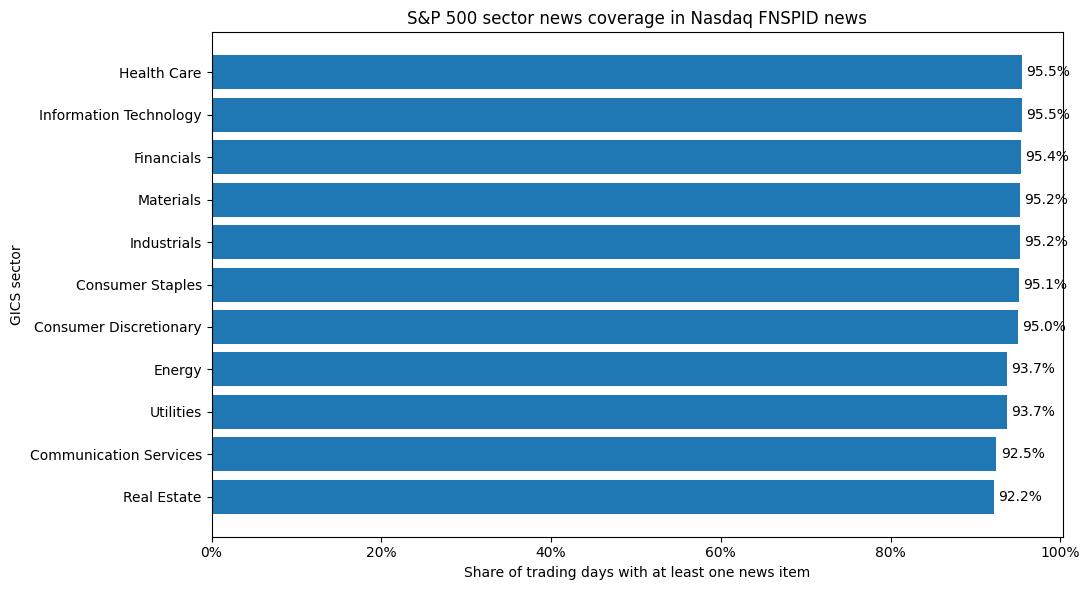

In [ ]:
plot_df = sector_stats.sort_values('share_trading_days_with_news')

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_df['gics_sector'],
    plot_df['share_trading_days_with_news']
)

ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Share of trading days with at least one news item')
ax.set_ylabel('GICS sector')
ax.set_title('S&P 500 sector news coverage in Nasdaq FNSPID news')

for i, value in enumerate(plot_df['share_trading_days_with_news']):
    ax.text(
        value + 0.005,
        i,
        f'{value:.1%}',
        va='center'
    )

plt.tight_layout()
plt.show()

In [ ]:
output_dir = project_dir / 'sector_news_coverage'
output_dir.mkdir(parents=True, exist_ok=True)

sp500_path = output_dir / 'sp500_current_gics_sectors.csv'
sector_day_path = output_dir / 'sp500_sector_news_trading_days.csv'
sector_stats_path = output_dir / 'sp500_sector_news_coverage_stats.csv'

sp500_df.to_csv(sp500_path, index=False)
sector_day_df.to_csv(sector_day_path, index=False)
sector_stats.to_csv(sector_stats_path, index=False)

print('saved:')
print(sp500_path)
print(sector_day_path)
print(sector_stats_path)

saved:
/content/fnspid_project/sector_news_coverage/sp500_current_gics_sectors.csv
/content/fnspid_project/sector_news_coverage/sp500_sector_news_trading_days.csv
/content/fnspid_project/sector_news_coverage/sp500_sector_news_coverage_stats.csv


## по Textrank_summary

In [ ]:
sample_df = pd.read_csv(news_path, nrows=5)

print('columns:')
print(sample_df.columns.tolist())

textrank_col = 'Textrank_summary'

if textrank_col not in sample_df.columns:
    raise KeyError(f'{textrank_col} was not found. Available columns: {sample_df.columns.tolist()}')

display(sample_df[[date_col, ticker_col, textrank_col]].head())

columns:
['Unnamed: 0', 'Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']


,Date,Stock_symbol,Textrank_summary
0,2023-12-16 23:00:00 UTC,A,Below is a chart showing the trailing twelve m...
1,2023-12-12 00:00:00 UTC,A,Agilent Technologies Declares $0.24 Dividend O...
2,2023-12-12 00:00:00 UTC,A,When a stock reaches the target an analyst has...
3,2023-12-07 00:00:00 UTC,A,"Agilent Technologies, Inc. Price and Consensus..."
4,2023-12-07 00:00:00 UTC,A,"The total Pre-Market volume is currently 39,23..."


In [ ]:
def is_nonempty_text_series(series):
    result = series.astype('string')
    result = result.str.strip()

    invalid_values = {
        '',
        'nan',
        'none',
        'null',
        'na',
        'n/a',
        '[]',
        '{}'
    }

    return result.notna() & ~result.str.lower().isin(invalid_values)

In [ ]:
ticker_to_sector = sp500_df.set_index('ticker_norm')['gics_sector'].to_dict()

textrank_sector_day_pairs = set()
textrank_sector_news_rows = {}

chunksize = 1_000_000
usecols = [date_col, ticker_col, textrank_col]

n_raw_rows = 0
n_nonempty_textrank_rows = 0
n_after_date_filter = 0
n_sp500_ticker_textrank_news_rows = 0

reader = pd.read_csv(
    news_path,
    usecols=usecols,
    chunksize=chunksize,
    dtype={
        ticker_col: 'string',
        textrank_col: 'string'
    },
    on_bad_lines='skip'
)

for chunk in tqdm(reader, desc='Processing Nasdaq news chunks with non-empty Textrank_summary'):
    n_raw_rows += len(chunk)

    nonempty_mask = is_nonempty_text_series(chunk[textrank_col])
    chunk = chunk[nonempty_mask].copy()

    n_nonempty_textrank_rows += len(chunk)

    if len(chunk) == 0:
        continue

    chunk[date_col] = pd.to_datetime(chunk[date_col], errors='coerce', utc=True)
    chunk['news_date'] = chunk[date_col].dt.tz_convert(None).dt.normalize()

    chunk = chunk[
        (chunk['news_date'] >= pd.Timestamp(start_date)) &
        (chunk['news_date'] <= pd.Timestamp(end_date))
    ].copy()

    n_after_date_filter += len(chunk)

    if len(chunk) == 0:
        continue

    ticker_raw = (
        chunk[ticker_col]
        .astype('string')
        .str.replace(r'[\[\]\{\}\(\)\'\"\$]', '', regex=True)
        .str.replace(r'\s+', '', regex=True)
    )

    chunk = chunk.assign(ticker_raw=ticker_raw.str.split(r'[,;|]+'))
    chunk = chunk.explode('ticker_raw')

    chunk['ticker_norm'] = normalize_ticker_series(chunk['ticker_raw'])
    chunk = chunk[chunk['ticker_norm'].notna()].copy()

    chunk['gics_sector'] = chunk['ticker_norm'].map(ticker_to_sector)
    chunk = chunk[chunk['gics_sector'].notna()].copy()

    if len(chunk) == 0:
        continue

    if weekend_policy == 'next_trading_day':
        chunk['trading_date'] = chunk['news_date'].map(date_to_trading_map)
        chunk = chunk[chunk['trading_date'].notna()].copy()
    elif weekend_policy == 'only_exact_trading_day':
        chunk = chunk[chunk['news_date'].isin(trading_days_set)].copy()
        chunk['trading_date'] = chunk['news_date']
    else:
        raise ValueError("weekend_policy must be 'next_trading_day' or 'only_exact_trading_day'")

    if len(chunk) == 0:
        continue

    n_sp500_ticker_textrank_news_rows += len(chunk)

    value_counts = chunk['gics_sector'].value_counts()
    for sector, count in value_counts.items():
        textrank_sector_news_rows[sector] = textrank_sector_news_rows.get(sector, 0) + int(count)

    pairs = chunk[['trading_date', 'gics_sector']].drop_duplicates()

    textrank_sector_day_pairs.update(
        (pd.Timestamp(trading_date).strftime('%Y-%m-%d'), sector)
        for trading_date, sector in pairs.itertuples(index=False, name=None)
    )

print('n_raw_rows:', n_raw_rows)
print('n_nonempty_textrank_rows:', n_nonempty_textrank_rows)
print('n_after_date_filter:', n_after_date_filter)
print('n_sp500_ticker_textrank_news_rows:', n_sp500_ticker_textrank_news_rows)
print('n_textrank_sector_day_pairs:', len(textrank_sector_day_pairs))

Processing Nasdaq news chunks with non-empty Textrank_summary: 0it [00:00, ?it/s]

n_raw_rows: 15549299
n_nonempty_textrank_rows: 2491778
n_after_date_filter: 2491708
n_sp500_ticker_textrank_news_rows: 729281
n_textrank_sector_day_pairs: 36011


In [ ]:
textrank_sector_day_df = pd.DataFrame(
    list(textrank_sector_day_pairs),
    columns=['trading_date', 'gics_sector']
)

textrank_sector_day_df['trading_date'] = pd.to_datetime(textrank_sector_day_df['trading_date'])

sector_constituent_counts = (
    sp500_df
    .groupby('gics_sector', as_index=False)
    .agg(n_sp500_tickers=('ticker_norm', 'nunique'))
)

textrank_sector_days_with_news = (
    textrank_sector_day_df
    .groupby('gics_sector', as_index=False)
    .agg(n_trading_days_with_nonempty_textrank=('trading_date', 'nunique'))
)

textrank_sector_news_rows_df = pd.DataFrame(
    list(textrank_sector_news_rows.items()),
    columns=['gics_sector', 'n_sp500_news_rows_with_nonempty_textrank']
)

textrank_sector_stats = (
    sector_constituent_counts
    .merge(textrank_sector_days_with_news, on='gics_sector', how='left')
    .merge(textrank_sector_news_rows_df, on='gics_sector', how='left')
)

textrank_sector_stats['n_trading_days_with_nonempty_textrank'] = (
    textrank_sector_stats['n_trading_days_with_nonempty_textrank']
    .fillna(0)
    .astype(int)
)

textrank_sector_stats['n_sp500_news_rows_with_nonempty_textrank'] = (
    textrank_sector_stats['n_sp500_news_rows_with_nonempty_textrank']
    .fillna(0)
    .astype(int)
)

textrank_sector_stats['n_trading_days_total'] = len(trading_days)

textrank_sector_stats['share_trading_days_with_nonempty_textrank'] = (
    textrank_sector_stats['n_trading_days_with_nonempty_textrank'] /
    textrank_sector_stats['n_trading_days_total']
)

textrank_sector_stats['share_trading_days_with_nonempty_textrank_pct'] = (
    100 * textrank_sector_stats['share_trading_days_with_nonempty_textrank']
)

textrank_sector_stats = textrank_sector_stats.sort_values(
    'share_trading_days_with_nonempty_textrank',
    ascending=False
).reset_index(drop=True)

display(textrank_sector_stats)

,gics_sector,n_sp500_tickers,n_trading_days_with_nonempty_textrank,n_sp500_news_rows_with_nonempty_textrank,n_trading_days_total,share_trading_days_with_nonempty_textrank,share_trading_days_with_nonempty_textrank_pct
0,Information Technology,73,3456,133931,3774,0.915739,91.573927
1,Financials,76,3450,103951,3774,0.914149,91.414944
2,Consumer Staples,36,3386,67433,3774,0.897191,89.719131
3,Industrials,79,3382,86557,3774,0.896131,89.613143
4,Consumer Discretionary,48,3376,81928,3774,0.894542,89.454160
5,Energy,22,3303,50831,3774,0.875199,87.519873
6,Health Care,58,3271,77384,3774,0.866720,86.671966
7,Communication Services,23,3128,48161,3774,0.828829,82.882883
8,Utilities,31,3121,33231,3774,0.826974,82.697403
9,Materials,26,3117,20775,3774,0.825914,82.591415


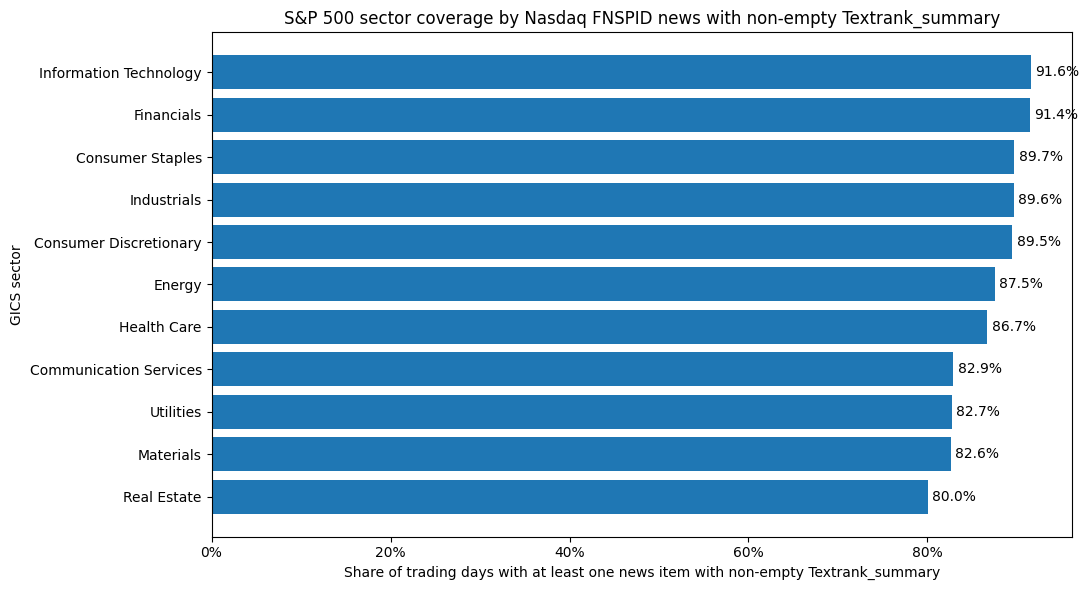

In [ ]:
plot_df = textrank_sector_stats.sort_values('share_trading_days_with_nonempty_textrank')

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_df['gics_sector'],
    plot_df['share_trading_days_with_nonempty_textrank']
)

ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Share of trading days with at least one news item with non-empty Textrank_summary')
ax.set_ylabel('GICS sector')
ax.set_title('S&P 500 sector coverage by Nasdaq FNSPID news with non-empty Textrank_summary')

for i, value in enumerate(plot_df['share_trading_days_with_nonempty_textrank']):
    ax.text(
        value + 0.005,
        i,
        f'{value:.1%}',
        va='center'
    )

plt.tight_layout()
plt.show()

In [ ]:
textrank_sector_stats

,gics_sector,n_sp500_tickers,n_trading_days_with_nonempty_textrank,n_sp500_news_rows_with_nonempty_textrank,n_trading_days_total,share_trading_days_with_nonempty_textrank,share_trading_days_with_nonempty_textrank_pct
0,Information Technology,73,3456,133931,3774,0.915739,91.573927
1,Financials,76,3450,103951,3774,0.914149,91.414944
2,Consumer Staples,36,3386,67433,3774,0.897191,89.719131
3,Industrials,79,3382,86557,3774,0.896131,89.613143
4,Consumer Discretionary,48,3376,81928,3774,0.894542,89.454160
5,Energy,22,3303,50831,3774,0.875199,87.519873
6,Health Care,58,3271,77384,3774,0.866720,86.671966
7,Communication Services,23,3128,48161,3774,0.828829,82.882883
8,Utilities,31,3121,33231,3774,0.826974,82.697403
9,Materials,26,3117,20775,3774,0.825914,82.591415


## FinBERT

In [ ]:
import os
import json
import subprocess
import sys
from pathlib import Path
from google.colab import userdata

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'],
    check=True
)

kaggle_username = userdata.get('KAGGLE_USERNAME')
kaggle_key = userdata.get('KAGGLE_KEY')

if kaggle_username is None:
    raise ValueError('KAGGLE_USERNAME is not found in Colab Secrets.')

if kaggle_key is None:
    raise ValueError('KAGGLE_KEY is not found in Colab Secrets.')

os.environ['KAGGLE_USERNAME'] = kaggle_username
os.environ['KAGGLE_KEY'] = kaggle_key

kaggle_dataset_slug = 'fnspid-sp500-textrank-finbert-features'
kaggle_dataset_title = 'FNSPID S&P 500 Textrank FinBERT Features'
kaggle_dataset_ref = f'{kaggle_username}/{kaggle_dataset_slug}'

kaggle_dataset_dir = Path('/content/kaggle_fnspid_sp500_textrank_finbert_features')
kaggle_dataset_dir.mkdir(parents=True, exist_ok=True)

metadata = {
    'title': kaggle_dataset_title,
    'id': kaggle_dataset_ref,
    'licenses': [
        {
            'name': 'CC0-1.0'
        }
    ]
}

metadata_path = kaggle_dataset_dir / 'dataset-metadata.json'

with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

readme_path = kaggle_dataset_dir / 'README.md'

readme_path.write_text(
    '# FNSPID S&P 500 Textrank FinBERT Features\n\n'
    'This dataset is a placeholder for FinBERT sentiment outputs and embeddings '
    'computed from non-empty Textrank summaries in FNSPID Nasdaq news for current '
    'S&P 500 constituents.\n',
    encoding='utf-8'
)

result = subprocess.run(
    [
        'kaggle',
        'datasets',
        'create',
        '-p',
        str(kaggle_dataset_dir),
        '--dir-mode',
        'zip'
    ],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    message = (result.stdout + '\n' + result.stderr).lower()
    if 'already' in message or 'exists' in message or 'slug' in message:
        print('Dataset probably already exists, continuing:', kaggle_dataset_ref)
    else:
        raise RuntimeError('Kaggle dataset creation failed.')

print('kaggle_dataset_ref:', kaggle_dataset_ref)
print('kaggle_dataset_dir:', kaggle_dataset_dir)

Starting upload for file README.md
Upload successful: README.md (218B)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/paveleshmeev/fnspid-sp500-textrank-finbert-features


  0%|          | 0.00/218 [00:00<?, ?B/s]
100%|██████████| 218/218 [00:00<00:00, 341B/s]

kaggle_dataset_ref: paveleshmeev/fnspid-sp500-textrank-finbert-features
kaggle_dataset_dir: /content/kaggle_fnspid_sp500_textrank_finbert_features


In [ ]:
import os
import re
import gc
import json
import sys
import subprocess
from io import StringIO
from pathlib import Path
from datetime import datetime

subprocess.run(
    [
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'transformers==4.45.2',
        'huggingface_hub==0.26.2',
        'accelerate',
        'pyarrow',
        'pandas_market_calendars',
        'lxml',
        'requests',
        'tqdm',
        'kaggle'
    ],
    check=True
)

import numpy as np
import pandas as pd
import requests
import torch
import pandas_market_calendars as mcal
from tqdm.auto import tqdm
from google.colab import userdata
from transformers import AutoTokenizer, AutoModelForSequenceClassification

kaggle_username = userdata.get('KAGGLE_USERNAME')
kaggle_key = userdata.get('KAGGLE_KEY')
hf_token = userdata.get('HF_TOKEN')

if kaggle_username is None:
    raise ValueError('KAGGLE_USERNAME is not found in Colab Secrets.')

if kaggle_key is None:
    raise ValueError('KAGGLE_KEY is not found in Colab Secrets.')

if hf_token is None:
    raise ValueError('HF_TOKEN is not found in Colab Secrets.')

os.environ['KAGGLE_USERNAME'] = kaggle_username
os.environ['KAGGLE_KEY'] = kaggle_key
os.environ['HF_TOKEN'] = hf_token

project_dir = Path('/content/fnspid_project')
raw_dir = project_dir / 'fnspid_raw'

try:
    news_path = Path(nasdaq_external_path)
except NameError:
    news_path = raw_dir / 'Stock_news' / 'nasdaq_exteral_data.csv'

if not news_path.exists():
    raise FileNotFoundError(f'News file not found: {news_path}')

kaggle_dataset_slug = 'fnspid-sp500-textrank-finbert-features'
kaggle_dataset_ref = f'{kaggle_username}/{kaggle_dataset_slug}'
kaggle_dataset_dir = Path('/content/kaggle_fnspid_sp500_textrank_finbert_features')
kaggle_dataset_dir.mkdir(parents=True, exist_ok=True)

metadata = {
    'title': 'FNSPID S&P 500 Textrank FinBERT Features',
    'id': kaggle_dataset_ref,
    'licenses': [
        {
            'name': 'CC0-1.0'
        }
    ]
}

with open(kaggle_dataset_dir / 'dataset-metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

start_date = '2009-01-01'
end_date = '2023-12-31'
weekend_policy = 'next_trading_day'

news_chunksize = 250_000
finbert_batch_size = 32
max_length = 512
model_name = 'ProsusAI/finbert'

overwrite_existing_parts = False

meta_dataset_dir = kaggle_dataset_dir / 'sp500_textrank_finbert_news_features.parquet'
mean_dataset_dir = kaggle_dataset_dir / 'sp500_textrank_finbert_mean_embeddings.parquet'
cls_dataset_dir = kaggle_dataset_dir / 'sp500_textrank_finbert_cls_embeddings.parquet'

meta_dataset_dir.mkdir(parents=True, exist_ok=True)
mean_dataset_dir.mkdir(parents=True, exist_ok=True)
cls_dataset_dir.mkdir(parents=True, exist_ok=True)

sp500_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

headers = {
    'User-Agent': (
        'Mozilla/5.0 (X11; Linux x86_64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    )
}

try:
    response = requests.get(sp500_url, headers=headers, timeout=30)
    response.raise_for_status()
    tables = pd.read_html(StringIO(response.text))
    sp500_raw = None

    for table in tables:
        if {'Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry'}.issubset(table.columns):
            sp500_raw = table.copy()
            break

    if sp500_raw is None:
        raise ValueError('S&P 500 table was not found on Wikipedia page.')
except Exception as e:
    print('Wikipedia loading failed, fallback to GitHub CSV:', repr(e))
    sp500_csv_url = (
        'https://raw.githubusercontent.com/datasets/'
        's-and-p-500-companies/main/data/constituents.csv'
    )
    sp500_raw = pd.read_csv(sp500_csv_url)

sp500_df = sp500_raw[
    ['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Date added']
].copy()

sp500_df.columns = [
    'ticker',
    'company_name',
    'gics_sector',
    'gics_sub_industry',
    'date_added'
]

sp500_df['ticker'] = sp500_df['ticker'].astype('string').str.upper().str.strip()
sp500_df['ticker_norm'] = sp500_df['ticker'].str.replace('-', '.', regex=False)
sp500_df['date_added'] = pd.to_datetime(sp500_df['date_added'], errors='coerce')
sp500_df = sp500_df.drop_duplicates('ticker_norm').reset_index(drop=True)

sp500_lookup_df = sp500_df[
    ['ticker_norm', 'ticker', 'company_name', 'gics_sector']
].copy()

ticker_to_company = sp500_lookup_df.set_index('ticker_norm')['company_name'].to_dict()
ticker_to_sector = sp500_lookup_df.set_index('ticker_norm')['gics_sector'].to_dict()
ticker_to_sp500_ticker = sp500_lookup_df.set_index('ticker_norm')['ticker'].to_dict()

nyse = mcal.get_calendar('NYSE')

map_end_date = (pd.Timestamp(end_date) + pd.Timedelta(days=10)).strftime('%Y-%m-%d')

schedule = nyse.schedule(
    start_date=start_date,
    end_date=map_end_date
)

trading_days_for_map = pd.DatetimeIndex(schedule.index).normalize()
trading_days = trading_days_for_map[
    (trading_days_for_map >= pd.Timestamp(start_date)) &
    (trading_days_for_map <= pd.Timestamp(end_date))
]

all_calendar_days = pd.date_range(start_date, end_date, freq='D').normalize()

trading_arr = trading_days_for_map.values.astype('datetime64[ns]')
calendar_arr = all_calendar_days.values.astype('datetime64[ns]')

positions = np.searchsorted(trading_arr, calendar_arr, side='left')

aligned_trading_days = np.full(
    shape=len(all_calendar_days),
    fill_value=np.datetime64('NaT'),
    dtype='datetime64[ns]'
)

valid_positions = positions < len(trading_arr)
aligned_trading_days[valid_positions] = trading_arr[positions[valid_positions]]

date_to_trading_df = pd.DataFrame({
    'news_date': all_calendar_days,
    'trading_date': pd.to_datetime(aligned_trading_days)
})

date_to_trading_df = date_to_trading_df[
    date_to_trading_df['trading_date'].notna()
].copy()

date_to_trading_df = date_to_trading_df[
    date_to_trading_df['trading_date'] <= pd.Timestamp(end_date)
].copy()

date_to_trading_map = dict(
    zip(date_to_trading_df['news_date'], date_to_trading_df['trading_date'])
)

sample_df = pd.read_csv(news_path, nrows=5)

def pick_col(columns, candidates):
    lower_to_original = {col.lower(): col for col in columns}
    for candidate in candidates:
        if candidate.lower() in lower_to_original:
            return lower_to_original[candidate.lower()]
    return None

ticker_candidates = [
    'Stock_symbol',
    'stock_symbol',
    'stock_symbols',
    'ticker',
    'Ticker',
    'symbol',
    'Symbol',
    'Stock Symbol',
    'stock'
]

date_candidates = [
    'Date',
    'date',
    'datetime',
    'Datetime',
    'published_at',
    'publish_date',
    'Publish_date',
    'time',
    'Time'
]

title_candidates = [
    'Title',
    'title',
    'headline',
    'Headline'
]

ticker_col = pick_col(sample_df.columns, ticker_candidates)
date_col = pick_col(sample_df.columns, date_candidates)
title_col = pick_col(sample_df.columns, title_candidates)
textrank_col = 'Textrank_summary'

if ticker_col is None:
    raise KeyError(f'Ticker column was not found. Available columns: {sample_df.columns.tolist()}')

if date_col is None:
    raise KeyError(f'Date column was not found. Available columns: {sample_df.columns.tolist()}')

if textrank_col not in sample_df.columns:
    raise KeyError(f'{textrank_col} was not found. Available columns: {sample_df.columns.tolist()}')

def normalize_ticker_series(series):
    result = series.astype('string').str.upper().str.strip()
    result = result.str.replace(r'[\[\]\{\}\(\)\'\"\$]', '', regex=True)
    result = result.str.replace(r'^[A-Z]+:', '', regex=True)
    result = result.str.replace('-', '.', regex=False)
    result = result.str.replace(r'[^A-Z0-9\.]', '', regex=True)
    result = result.replace('', pd.NA)
    return result

def is_nonempty_text_series(series):
    result = series.astype('string').str.strip()

    invalid_values = {
        '',
        'nan',
        'none',
        'null',
        'na',
        'n/a',
        '[]',
        '{}'
    }

    return result.notna() & ~result.str.lower().isin(invalid_values)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    token=hf_token
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    token=hf_token
)

model.to(device)
model.eval()

hidden_size = int(model.config.hidden_size)

id2label = {
    int(k): str(v).lower()
    for k, v in model.config.id2label.items()
}

if not {'positive', 'negative', 'neutral'}.issubset(set(id2label.values())):
    id2label = {
        0: 'positive',
        1: 'negative',
        2: 'neutral'
    }

label_to_idx = {
    label: idx
    for idx, label in id2label.items()
}

meta_columns = [
    'news_id',
    'source_row_id',
    'published_at',
    'news_date',
    'trading_date',
    'ticker',
    'ticker_original',
    'company_name',
    'gics_sector',
    'title',
    'input_was_truncated',
    'finbert_positive_prob',
    'finbert_negative_prob',
    'finbert_neutral_prob',
    'finbert_label',
    'finbert_confidence',
    'sentiment_score',
    'sentiment_abs_score',
    'is_positive',
    'is_negative',
    'is_neutral'
]

embedding_key_columns = [
    'news_id',
    'news_date',
    'trading_date',
    'ticker',
    'ticker_original',
    'gics_sector'
]

mean_columns = embedding_key_columns + [
    f'mean_emb_{i}'
    for i in range(hidden_size)
]

cls_columns = embedding_key_columns + [
    f'cls_emb_{i}'
    for i in range(hidden_size)
]

def run_finbert(texts):
    n = len(texts)

    positive_probs = []
    negative_probs = []
    neutral_probs = []
    labels = []
    confidences = []
    truncated_flags = []
    cls_embeddings = []
    mean_embeddings = []

    for start in tqdm(range(0, n, finbert_batch_size), desc='FinBERT batches', leave=False):
        batch_texts = texts[start:start + finbert_batch_size]

        length_encoding = tokenizer(
            batch_texts,
            add_special_tokens=True,
            truncation=False,
            padding=False,
            return_length=True
        )

        batch_lengths = np.array(length_encoding['length'])
        batch_truncated = batch_lengths > max_length

        encoding = tokenizer(
            batch_texts,
            add_special_tokens=True,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )

        encoding = {
            key: value.to(device)
            for key, value in encoding.items()
        }

        with torch.inference_mode():
            outputs = model(
                **encoding,
                output_hidden_states=True,
                return_dict=True
            )

            logits = outputs.logits.float()
            probs = torch.softmax(logits, dim=-1)

            last_hidden_state = outputs.hidden_states[-1].float()
            attention_mask = encoding['attention_mask']
            attention_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()

            mean_embedding = (
                (last_hidden_state * attention_mask_expanded).sum(dim=1) /
                attention_mask_expanded.sum(dim=1).clamp(min=1e-9)
            )

            cls_embedding = last_hidden_state[:, 0, :]

            probs_np = probs.detach().cpu().numpy().astype(np.float32)
            pred_idx = probs_np.argmax(axis=1)

            cls_np = cls_embedding.detach().cpu().numpy().astype(np.float32)
            mean_np = mean_embedding.detach().cpu().numpy().astype(np.float32)

        positive_idx = label_to_idx['positive']
        negative_idx = label_to_idx['negative']
        neutral_idx = label_to_idx['neutral']

        positive_probs.append(probs_np[:, positive_idx])
        negative_probs.append(probs_np[:, negative_idx])
        neutral_probs.append(probs_np[:, neutral_idx])
        labels.extend([id2label[int(idx)] for idx in pred_idx])
        confidences.append(probs_np.max(axis=1))
        truncated_flags.append(batch_truncated)
        cls_embeddings.append(cls_np)
        mean_embeddings.append(mean_np)

    result = {
        'positive_prob': np.concatenate(positive_probs).astype(np.float32),
        'negative_prob': np.concatenate(negative_probs).astype(np.float32),
        'neutral_prob': np.concatenate(neutral_probs).astype(np.float32),
        'label': np.array(labels, dtype=object),
        'confidence': np.concatenate(confidences).astype(np.float32),
        'input_was_truncated': np.concatenate(truncated_flags).astype(bool),
        'cls_embeddings': np.vstack(cls_embeddings).astype(np.float32),
        'mean_embeddings': np.vstack(mean_embeddings).astype(np.float32)
    }

    return result

def write_empty_parts(part_idx):
    meta_part_path = meta_dataset_dir / f'part_{part_idx:05d}.parquet'
    mean_part_path = mean_dataset_dir / f'part_{part_idx:05d}.parquet'
    cls_part_path = cls_dataset_dir / f'part_{part_idx:05d}.parquet'

    pd.DataFrame(columns=meta_columns).to_parquet(
        meta_part_path,
        index=False,
        compression='zstd'
    )

    pd.DataFrame(columns=mean_columns).to_parquet(
        mean_part_path,
        index=False,
        compression='zstd'
    )

    pd.DataFrame(columns=cls_columns).to_parquet(
        cls_part_path,
        index=False,
        compression='zstd'
    )

usecols = [date_col, ticker_col, textrank_col]

if title_col is not None:
    usecols.append(title_col)

reader = pd.read_csv(
    news_path,
    usecols=usecols,
    chunksize=news_chunksize,
    dtype={
        ticker_col: 'string',
        textrank_col: 'string'
    },
    on_bad_lines='skip'
)

processing_summary = {
    'started_at': datetime.utcnow().isoformat(),
    'news_path': str(news_path),
    'model_name': model_name,
    'start_date': start_date,
    'end_date': end_date,
    'weekend_policy': weekend_policy,
    'news_chunksize': news_chunksize,
    'finbert_batch_size': finbert_batch_size,
    'max_length': max_length,
    'hidden_size': hidden_size,
    'device': str(device),
    'n_sp500_current_constituents': int(sp500_df['ticker_norm'].nunique()),
    'n_raw_rows_seen': 0,
    'n_rows_with_nonempty_textrank': 0,
    'n_rows_after_date_filter': 0,
    'n_news_ticker_rows_after_sp500_filter': 0,
    'n_unique_texts_sent_to_finbert': 0,
    'n_parts_written': 0,
    'n_parts_skipped_existing': 0,
    'n_empty_parts_written': 0
}

source_row_start = 0

for part_idx, chunk in enumerate(tqdm(reader, desc='Processing news chunks')):
    original_len = len(chunk)

    meta_part_path = meta_dataset_dir / f'part_{part_idx:05d}.parquet'
    mean_part_path = mean_dataset_dir / f'part_{part_idx:05d}.parquet'
    cls_part_path = cls_dataset_dir / f'part_{part_idx:05d}.parquet'

    part_exists = (
        meta_part_path.exists() and
        mean_part_path.exists() and
        cls_part_path.exists()
    )

    if part_exists and not overwrite_existing_parts:
        processing_summary['n_raw_rows_seen'] += int(original_len)
        processing_summary['n_parts_skipped_existing'] += 1
        source_row_start += original_len
        continue

    chunk = chunk.copy()
    chunk['source_row_id'] = np.arange(
        source_row_start,
        source_row_start + original_len,
        dtype=np.int64
    )

    source_row_start += original_len
    processing_summary['n_raw_rows_seen'] += int(original_len)

    nonempty_mask = is_nonempty_text_series(chunk[textrank_col])
    chunk = chunk[nonempty_mask].copy()
    processing_summary['n_rows_with_nonempty_textrank'] += int(len(chunk))

    if len(chunk) == 0:
        write_empty_parts(part_idx)
        processing_summary['n_empty_parts_written'] += 1
        processing_summary['n_parts_written'] += 1
        continue

    chunk['published_at'] = pd.to_datetime(
        chunk[date_col],
        errors='coerce',
        utc=True
    ).dt.tz_convert(None)

    chunk['news_date'] = chunk['published_at'].dt.normalize()

    chunk = chunk[
        (chunk['news_date'] >= pd.Timestamp(start_date)) &
        (chunk['news_date'] <= pd.Timestamp(end_date))
    ].copy()

    processing_summary['n_rows_after_date_filter'] += int(len(chunk))

    if len(chunk) == 0:
        write_empty_parts(part_idx)
        processing_summary['n_empty_parts_written'] += 1
        processing_summary['n_parts_written'] += 1
        continue

    if weekend_policy == 'next_trading_day':
        chunk['trading_date'] = chunk['news_date'].map(date_to_trading_map)
        chunk = chunk[chunk['trading_date'].notna()].copy()
    else:
        raise ValueError("Only weekend_policy='next_trading_day' is configured in this block.")

    if len(chunk) == 0:
        write_empty_parts(part_idx)
        processing_summary['n_empty_parts_written'] += 1
        processing_summary['n_parts_written'] += 1
        continue

    ticker_raw = (
        chunk[ticker_col]
        .astype('string')
        .str.replace(r'[\[\]\{\}\(\)\'\"\$]', '', regex=True)
        .str.replace(r'\s+', '', regex=True)
    )

    chunk = chunk.assign(ticker_original=ticker_raw.str.split(r'[,;|]+', regex=True))
    chunk = chunk.explode('ticker_original')

    chunk['ticker_norm'] = normalize_ticker_series(chunk['ticker_original'])
    chunk = chunk[chunk['ticker_norm'].notna()].copy()

    chunk['ticker'] = chunk['ticker_norm'].map(ticker_to_sp500_ticker)
    chunk['company_name'] = chunk['ticker_norm'].map(ticker_to_company)
    chunk['gics_sector'] = chunk['ticker_norm'].map(ticker_to_sector)

    chunk = chunk[
        chunk['ticker'].notna() &
        chunk['company_name'].notna() &
        chunk['gics_sector'].notna()
    ].copy()

    if len(chunk) == 0:
        write_empty_parts(part_idx)
        processing_summary['n_empty_parts_written'] += 1
        processing_summary['n_parts_written'] += 1
        continue

    chunk = chunk.drop_duplicates(['source_row_id', 'ticker']).copy()

    chunk['news_id'] = (
        'fnspid_nasdaq_' +
        chunk['source_row_id'].astype(str) +
        '_' +
        chunk['ticker'].astype(str)
    )

    if title_col is None:
        chunk['title'] = pd.NA
    else:
        chunk['title'] = chunk[title_col].astype('string')

    chunk['finbert_input_text'] = chunk[textrank_col].astype('string').str.strip()

    chunk = chunk[
        [
            'news_id',
            'source_row_id',
            'published_at',
            'news_date',
            'trading_date',
            'ticker',
            'ticker_original',
            'company_name',
            'gics_sector',
            'title',
            'finbert_input_text'
        ]
    ].copy()

    chunk = chunk.reset_index(drop=True)

    processing_summary['n_news_ticker_rows_after_sp500_filter'] += int(len(chunk))

    unique_text_df = (
        chunk[['source_row_id', 'finbert_input_text']]
        .drop_duplicates('source_row_id')
        .reset_index(drop=True)
    )

    texts = unique_text_df['finbert_input_text'].astype(str).tolist()

    processing_summary['n_unique_texts_sent_to_finbert'] += int(len(unique_text_df))

    finbert_result = run_finbert(texts)

    source_to_unique_pos = {
        int(source_row_id): pos
        for pos, source_row_id in enumerate(unique_text_df['source_row_id'].tolist())
    }

    row_positions = chunk['source_row_id'].map(source_to_unique_pos).to_numpy()

    positive_prob = finbert_result['positive_prob'][row_positions]
    negative_prob = finbert_result['negative_prob'][row_positions]
    neutral_prob = finbert_result['neutral_prob'][row_positions]
    label = finbert_result['label'][row_positions]
    confidence = finbert_result['confidence'][row_positions]
    input_was_truncated = finbert_result['input_was_truncated'][row_positions]

    sentiment_score = positive_prob - negative_prob
    sentiment_abs_score = np.abs(sentiment_score)

    meta_df = chunk[
        [
            'news_id',
            'source_row_id',
            'published_at',
            'news_date',
            'trading_date',
            'ticker',
            'ticker_original',
            'company_name',
            'gics_sector',
            'title'
        ]
    ].copy()

    meta_df['input_was_truncated'] = input_was_truncated
    meta_df['finbert_positive_prob'] = positive_prob.astype(np.float32)
    meta_df['finbert_negative_prob'] = negative_prob.astype(np.float32)
    meta_df['finbert_neutral_prob'] = neutral_prob.astype(np.float32)
    meta_df['finbert_label'] = label
    meta_df['finbert_confidence'] = confidence.astype(np.float32)
    meta_df['sentiment_score'] = sentiment_score.astype(np.float32)
    meta_df['sentiment_abs_score'] = sentiment_abs_score.astype(np.float32)
    meta_df['is_positive'] = meta_df['finbert_label'].eq('positive')
    meta_df['is_negative'] = meta_df['finbert_label'].eq('negative')
    meta_df['is_neutral'] = meta_df['finbert_label'].eq('neutral')

    meta_df = meta_df[meta_columns].copy()

    embedding_keys_df = chunk[
        [
            'news_id',
            'news_date',
            'trading_date',
            'ticker',
            'ticker_original',
            'gics_sector'
        ]
    ].copy()

    mean_matrix = finbert_result['mean_embeddings'][row_positions]
    cls_matrix = finbert_result['cls_embeddings'][row_positions]

    mean_df = pd.concat(
        [
            embedding_keys_df.reset_index(drop=True),
            pd.DataFrame(
                mean_matrix,
                columns=[f'mean_emb_{i}' for i in range(hidden_size)]
            )
        ],
        axis=1
    )

    cls_df = pd.concat(
        [
            embedding_keys_df.reset_index(drop=True),
            pd.DataFrame(
                cls_matrix,
                columns=[f'cls_emb_{i}' for i in range(hidden_size)]
            )
        ],
        axis=1
    )

    meta_df.to_parquet(
        meta_part_path,
        index=False,
        compression='zstd'
    )

    mean_df.to_parquet(
        mean_part_path,
        index=False,
        compression='zstd'
    )

    cls_df.to_parquet(
        cls_part_path,
        index=False,
        compression='zstd'
    )

    processing_summary['n_parts_written'] += 1

    del chunk
    del unique_text_df
    del texts
    del finbert_result
    del meta_df
    del mean_df
    del cls_df
    del mean_matrix
    del cls_matrix

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

processing_summary['finished_at'] = datetime.utcnow().isoformat()

summary_path = kaggle_dataset_dir / 'processing_summary.json'

with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(processing_summary, f, ensure_ascii=False, indent=2)

schema_info = {
    'sp500_textrank_finbert_news_features.parquet': {
        'description': 'Metadata and FinBERT sentiment outputs. One row is one news-ticker observation.',
        'columns': meta_columns
    },
    'sp500_textrank_finbert_mean_embeddings.parquet': {
        'description': 'Mean-pooled FinBERT embeddings. One row is one news-ticker observation.',
        'columns': mean_columns
    },
    'sp500_textrank_finbert_cls_embeddings.parquet': {
        'description': 'CLS FinBERT embeddings. One row is one news-ticker observation.',
        'columns': cls_columns
    }
}

with open(kaggle_dataset_dir / 'schema_info.json', 'w', encoding='utf-8') as f:
    json.dump(schema_info, f, ensure_ascii=False, indent=2)

readme_text = f"""# FNSPID S&P 500 Textrank FinBERT Features

This dataset contains FinBERT sentiment outputs and embeddings computed from non-empty Textrank summaries in FNSPID Nasdaq news for current S&P 500 constituents.

## Files

- `sp500_textrank_finbert_news_features.parquet/`: metadata and FinBERT sentiment outputs.
- `sp500_textrank_finbert_mean_embeddings.parquet/`: mean-pooled FinBERT embeddings.
- `sp500_textrank_finbert_cls_embeddings.parquet/`: CLS FinBERT embeddings.
- `processing_summary.json`: processing parameters and counters.
- `schema_info.json`: column schema.

## Processing setup

- Model: `{model_name}`
- Period: `{start_date}` to `{end_date}`
- Weekend policy: news published on a non-trading day is assigned to the next NYSE trading day.
- Max token length: `{max_length}`
- FinBERT batch size: `{finbert_batch_size}`
- Hidden size: `{hidden_size}`
- Device: `{device}`

## Important note

The S&P 500 membership and GICS sector mapping are based on the current constituent table used at processing time, not a historical constituent panel.
"""

(kaggle_dataset_dir / 'README.md').write_text(readme_text, encoding='utf-8')

print('processing_summary:')
print(json.dumps(processing_summary, ensure_ascii=False, indent=2))

print('output files:')
print(meta_dataset_dir)
print(mean_dataset_dir)
print(cls_dataset_dir)
print(summary_path)

version_message = (
    'Add FNSPID S&P 500 Textrank FinBERT sentiment outputs, '
    'mean-pooled embeddings and CLS embeddings'
)

result = subprocess.run(
    [
        'kaggle',
        'datasets',
        'version',
        '-p',
        str(kaggle_dataset_dir),
        '-m',
        version_message,
        '--dir-mode',
        'zip'
    ],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError('Kaggle dataset version upload failed.')

print('Kaggle dataset updated:', kaggle_dataset_ref)

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

FinBERT batches:   0%|          | 0/1954 [00:00<?, ?it/s]

FinBERT batches:   0%|          | 0/2267 [00:00<?, ?it/s]

FinBERT batches:   0%|          | 0/1701 [00:00<?, ?it/s]

/tmp/ipykernel_1122/2558712162.py:788: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  processing_summary['finished_at'] = datetime.utcnow().isoformat()


processing_summary:
{
  "started_at": "2026-05-06T12:54:56.720214",
  "news_path": "/content/fnspid_project/fnspid_raw/Stock_news/nasdaq_exteral_data.csv",
  "model_name": "ProsusAI/finbert",
  "start_date": "2009-01-01",
  "end_date": "2023-12-31",
  "weekend_policy": "next_trading_day",
  "news_chunksize": 250000,
  "finbert_batch_size": 32,
  "max_length": 512,
  "hidden_size": 768,
  "device": "cuda",
  "n_sp500_current_constituents": 503,
  "n_raw_rows_seen": 15549299,
  "n_rows_with_nonempty_textrank": 2491778,
  "n_rows_after_date_filter": 2491708,
  "n_news_ticker_rows_after_sp500_filter": 729281,
  "n_unique_texts_sent_to_finbert": 729281,
  "n_parts_written": 63,
  "n_parts_skipped_existing": 0,
  "n_empty_parts_written": 53,
  "finished_at": "2026-05-06T16:27:44.282136"
}
output files:
/content/kaggle_fnspid_sp500_textrank_finbert_features/sp500_textrank_finbert_news_features.parquet
/content/kaggle_fnspid_sp500_textrank_finbert_features/sp500_textrank_finbert_mean_embedding

# Средняя статистика по дням

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

data_dir = Path('/kaggle/input/fnspid-sp500-textrank-finbert-features')

if not data_dir.exists():
    data_dir = Path('/content/kaggle_fnspid_sp500_textrank_finbert_features')

meta_path = data_dir / 'sp500_textrank_finbert_news_features.parquet'

meta_df = pd.read_parquet(
    meta_path,
    columns=[
        'news_id',
        'trading_date',
        'gics_sector',
        'ticker'
    ]
)

meta_df['trading_date'] = pd.to_datetime(meta_df['trading_date']).dt.normalize()

print('meta_df shape:', meta_df.shape)
display(meta_df.head())

meta_df shape: (729281, 4)


,news_id,trading_date,gics_sector,ticker
0,fnspid_nasdaq_0_A,2023-12-18,Health Care,A
1,fnspid_nasdaq_1_A,2023-12-12,Health Care,A
2,fnspid_nasdaq_2_A,2023-12-12,Health Care,A
3,fnspid_nasdaq_3_A,2023-12-07,Health Care,A
4,fnspid_nasdaq_4_A,2023-12-07,Health Care,A


In [ ]:
daily_sector_news = (
    meta_df
    .groupby(['gics_sector', 'trading_date'], as_index=False)
    .agg(
        n_news=('news_id', 'count'),
        n_unique_news=('news_id', 'nunique'),
        n_tickers_with_news=('ticker', 'nunique')
    )
)

display(daily_sector_news.head())

,gics_sector,trading_date,n_news,n_unique_news,n_tickers_with_news
0,Communication Services,2009-11-17,1,1,1
1,Communication Services,2009-11-25,1,1,1
2,Communication Services,2009-12-18,1,1,1
3,Communication Services,2010-01-27,1,1,1
4,Communication Services,2010-02-01,1,1,1


In [ ]:
all_sectors = sorted(meta_df['gics_sector'].dropna().unique())
all_trading_days = pd.date_range(
    meta_df['trading_date'].min(),
    meta_df['trading_date'].max(),
    freq='B'
)

full_index = pd.MultiIndex.from_product(
    [all_sectors, all_trading_days],
    names=['gics_sector', 'trading_date']
)

daily_sector_news_full = (
    daily_sector_news
    .set_index(['gics_sector', 'trading_date'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

display(daily_sector_news_full.head())

,gics_sector,trading_date,n_news,n_unique_news,n_tickers_with_news
0,Communication Services,2009-07-07,0,0,0
1,Communication Services,2009-07-08,0,0,0
2,Communication Services,2009-07-09,0,0,0
3,Communication Services,2009-07-10,0,0,0
4,Communication Services,2009-07-13,0,0,0


In [ ]:
import pandas_market_calendars as mcal

nyse = mcal.get_calendar('NYSE')

schedule = nyse.schedule(
    start_date=meta_df['trading_date'].min(),
    end_date=meta_df['trading_date'].max()
)

all_trading_days = pd.DatetimeIndex(schedule.index).normalize()

full_index = pd.MultiIndex.from_product(
    [all_sectors, all_trading_days],
    names=['gics_sector', 'trading_date']
)

daily_sector_news_full = (
    daily_sector_news
    .set_index(['gics_sector', 'trading_date'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

display(daily_sector_news_full.head())

,gics_sector,trading_date,n_news,n_unique_news,n_tickers_with_news
0,Communication Services,2009-07-07,0,0,0
1,Communication Services,2009-07-08,0,0,0
2,Communication Services,2009-07-09,0,0,0
3,Communication Services,2009-07-10,0,0,0
4,Communication Services,2009-07-13,0,0,0


In [ ]:
sector_daily_stats = (
    daily_sector_news_full
    .groupby('gics_sector', as_index=False)
    .agg(
        n_trading_days_total=('trading_date', 'nunique'),
        n_trading_days_with_news=('n_news', lambda x: int((x > 0).sum())),
        total_news=('n_news', 'sum'),
        avg_news_per_all_trading_day=('n_news', 'mean'),
        median_news_per_all_trading_day=('n_news', 'median'),
        std_news_per_all_trading_day=('n_news', 'std'),
        min_news_per_day=('n_news', 'min'),
        max_news_per_day=('n_news', 'max'),
        avg_unique_news_per_all_trading_day=('n_unique_news', 'mean'),
        avg_tickers_with_news_per_all_trading_day=('n_tickers_with_news', 'mean')
    )
)

sector_daily_stats['share_trading_days_with_news'] = (
    sector_daily_stats['n_trading_days_with_news'] /
    sector_daily_stats['n_trading_days_total']
)

news_days_only = daily_sector_news_full[daily_sector_news_full['n_news'] > 0].copy()

sector_news_day_stats = (
    news_days_only
    .groupby('gics_sector', as_index=False)
    .agg(
        avg_news_per_news_day=('n_news', 'mean'),
        median_news_per_news_day=('n_news', 'median'),
        avg_unique_news_per_news_day=('n_unique_news', 'mean'),
        avg_tickers_with_news_per_news_day=('n_tickers_with_news', 'mean')
    )
)

sector_daily_stats = (
    sector_daily_stats
    .merge(sector_news_day_stats, on='gics_sector', how='left')
    .sort_values('avg_news_per_all_trading_day', ascending=False)
    .reset_index(drop=True)
)

display(sector_daily_stats)

,gics_sector,n_trading_days_total,n_trading_days_with_news,total_news,avg_news_per_all_trading_day,median_news_per_all_trading_day,std_news_per_all_trading_day,min_news_per_day,max_news_per_day,avg_unique_news_per_all_trading_day,avg_tickers_with_news_per_all_trading_day,share_trading_days_with_news,avg_news_per_news_day,median_news_per_news_day,avg_unique_news_per_news_day,avg_tickers_with_news_per_news_day
0,Information Technology,3647,3456,133931,36.723608,22.0,45.394980,0,372,36.723608,13.565945,0.947628,38.753183,24.0,38.753183,14.315683
1,Financials,3647,3450,103951,28.503153,24.0,24.651213,0,209,28.503153,13.583493,0.945983,30.130725,26.0,30.130725,14.359130
2,Industrials,3647,3382,86557,23.733754,19.0,21.575013,0,167,23.733754,12.298053,0.927338,25.593436,20.0,25.593436,13.261679
3,Consumer Discretionary,3647,3376,81928,22.464491,16.0,25.110404,0,209,22.464491,9.385248,0.925692,24.267773,18.0,24.267773,10.138626
4,Health Care,3647,3271,77384,21.218536,19.0,17.675961,0,165,21.218536,10.603784,0.896902,23.657597,21.0,23.657597,11.822684
5,Consumer Staples,3647,3386,67433,18.489992,15.0,16.687895,0,169,18.489992,8.215245,0.928434,19.915239,16.0,19.915239,8.848494
6,Energy,3647,3303,50831,13.937757,9.0,15.551208,0,108,13.937757,5.735125,0.905676,15.389343,10.0,15.389343,6.332425
7,Communication Services,3647,3128,48161,13.205648,9.0,13.232672,0,72,13.205648,4.025775,0.857691,15.396739,12.0,15.396739,4.693734
8,Utilities,3647,3121,33231,9.111873,7.0,8.816536,0,69,9.111873,5.778174,0.855772,10.647549,8.0,10.647549,6.752003
9,Real Estate,3647,3021,25099,6.882095,5.0,7.721413,0,63,6.882095,4.126405,0.828352,8.308176,6.0,8.308176,4.981463


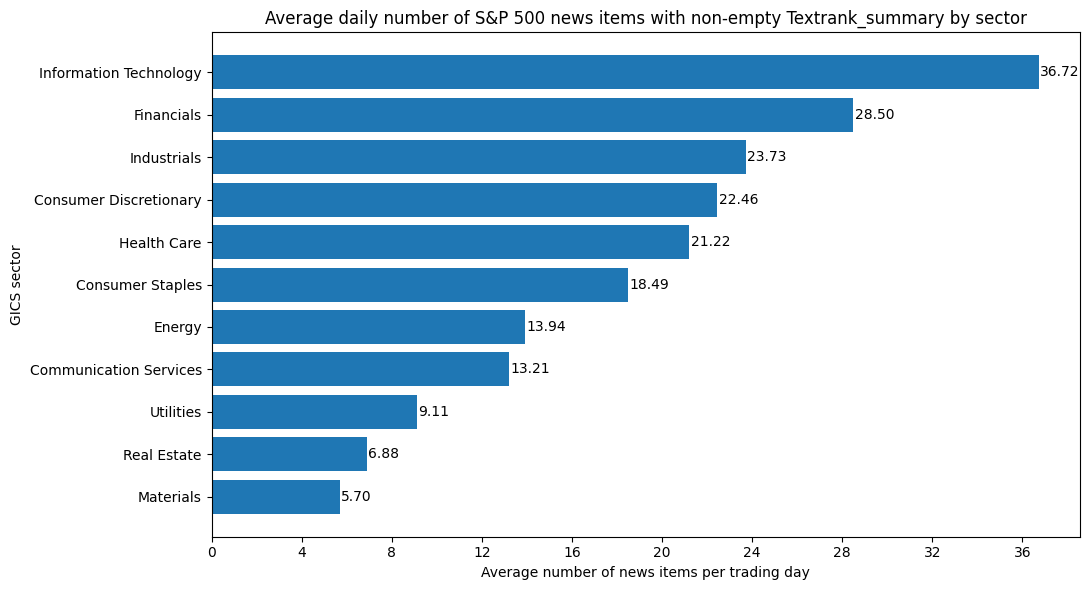

In [ ]:
plot_df = sector_daily_stats.sort_values('avg_news_per_all_trading_day')

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_df['gics_sector'],
    plot_df['avg_news_per_all_trading_day']
)

ax.set_xlabel('Average number of news items per trading day')
ax.set_ylabel('GICS sector')
ax.set_title('Average daily number of S&P 500 news items with non-empty Textrank_summary by sector')
ax.xaxis.set_major_locator(MaxNLocator(integer=False))

for i, value in enumerate(plot_df['avg_news_per_all_trading_day']):
    ax.text(
        value + 0.05,
        i,
        f'{value:.2f}',
        va='center'
    )

plt.tight_layout()
plt.show()

## Сбор средних по сектору эмбеддингов

In [ ]:
from pathlib import Path
import os
import json
import shutil
import subprocess
import sys
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal

dataset_ref = 'paveleshmeev/fnspid-sp500-textrank-finbert-features'
dataset_slug = 'fnspid-sp500-textrank-finbert-features'

candidate_dirs = [
    Path('/kaggle/input') / dataset_slug,
    Path('/content/kaggle_fnspid_sp500_textrank_finbert_features'),
    Path('/content') / dataset_slug
]

data_dir = None

for candidate_dir in candidate_dirs:
    if candidate_dir.exists():
        data_dir = candidate_dir
        break

if data_dir is None:
    try:
        from google.colab import userdata

        kaggle_username = userdata.get('KAGGLE_USERNAME')
        kaggle_key = userdata.get('KAGGLE_KEY')

        if kaggle_username is None:
            raise ValueError('KAGGLE_USERNAME is not found in Colab Secrets.')

        if kaggle_key is None:
            raise ValueError('KAGGLE_KEY is not found in Colab Secrets.')

        os.environ['KAGGLE_USERNAME'] = kaggle_username
        os.environ['KAGGLE_KEY'] = kaggle_key

        download_dir = Path('/content/kaggle_input')
        download_dir.mkdir(parents=True, exist_ok=True)

        subprocess.run(
            [
                'kaggle',
                'datasets',
                'download',
                '-d',
                dataset_ref,
                '-p',
                str(download_dir),
                '--unzip'
            ],
            check=True
        )

        data_dir = download_dir
    except Exception as e:
        raise RuntimeError(
            'Dataset directory was not found and Kaggle download failed. '
            'Attach the Kaggle dataset or add Kaggle secrets.'
        ) from e

print('data_dir:', data_dir)

meta_path = data_dir / 'sp500_textrank_finbert_news_features.parquet'
mean_path = data_dir / 'sp500_textrank_finbert_mean_embeddings.parquet'
cls_path = data_dir / 'sp500_textrank_finbert_cls_embeddings.parquet'

for path in [meta_path, mean_path, cls_path]:
    if not path.exists():
        raise FileNotFoundError(f'Path not found: {path}')

output_dir = Path('/content/fnspid_project/sector_top5_directional_embeddings')
output_dir.mkdir(parents=True, exist_ok=True)

top_k = 5
include_all_sector_trading_days = True
upload_to_kaggle = False

meta_cols = [
    'news_id',
    'trading_date',
    'gics_sector',
    'ticker',
    'finbert_positive_prob',
    'finbert_negative_prob',
    'finbert_neutral_prob',
    'finbert_label',
    'finbert_confidence',
    'is_positive',
    'is_negative',
    'is_neutral'
]

meta_df = pd.read_parquet(meta_path, columns=meta_cols)

meta_df['trading_date'] = pd.to_datetime(meta_df['trading_date']).dt.normalize()
meta_df['gics_sector'] = meta_df['gics_sector'].astype('string')
meta_df['ticker'] = meta_df['ticker'].astype('string')
meta_df['news_id'] = meta_df['news_id'].astype('string')

for col in ['finbert_positive_prob', 'finbert_negative_prob', 'finbert_neutral_prob', 'finbert_confidence']:
    meta_df[col] = pd.to_numeric(meta_df[col], errors='coerce').astype('float32')

for col in ['is_positive', 'is_negative', 'is_neutral']:
    if meta_df[col].dtype != bool:
        meta_df[col] = meta_df[col].astype('bool')

meta_df = meta_df[
    meta_df['news_id'].notna() &
    meta_df['trading_date'].notna() &
    meta_df['gics_sector'].notna()
].copy()

meta_df['directional_confidence'] = meta_df[
    ['finbert_positive_prob', 'finbert_negative_prob']
].max(axis=1)

meta_df['is_directional'] = ~meta_df['is_neutral']
meta_df['selection_priority'] = meta_df['is_directional'].astype('int8')

meta_df['selection_score'] = np.where(
    meta_df['is_directional'],
    meta_df['finbert_confidence'],
    meta_df['directional_confidence']
).astype('float32')

ranked_news_df = (
    meta_df
    .sort_values(
        [
            'gics_sector',
            'trading_date',
            'selection_priority',
            'selection_score',
            'directional_confidence',
            'finbert_confidence',
            'news_id'
        ],
        ascending=[
            True,
            True,
            False,
            False,
            False,
            False,
            True
        ]
    )
    .copy()
)

selected_news_df = (
    ranked_news_df
    .groupby(['gics_sector', 'trading_date'], group_keys=False)
    .head(top_k)
    .copy()
)

selected_news_df['selected_rank'] = (
    selected_news_df
    .groupby(['gics_sector', 'trading_date'])
    .cumcount() + 1
)

selected_news_df['selection_type'] = np.where(
    selected_news_df['is_directional'],
    'non_neutral_by_finbert_confidence',
    'fallback_by_directional_confidence'
)

selected_news_df = selected_news_df[
    [
        'news_id',
        'gics_sector',
        'trading_date',
        'ticker',
        'selected_rank',
        'selection_type',
        'is_directional',
        'finbert_positive_prob',
        'finbert_negative_prob',
        'finbert_neutral_prob',
        'finbert_confidence',
        'directional_confidence',
        'finbert_label'
    ]
].copy()

selected_news_df['news_id'] = selected_news_df['news_id'].astype('string')

selected_news_ids = set(selected_news_df['news_id'].astype(str).tolist())

selected_stats = (
    selected_news_df
    .sort_values(['gics_sector', 'trading_date', 'selected_rank'])
    .groupby(['gics_sector', 'trading_date'], as_index=False)
    .agg(
        n_selected_news=('news_id', 'count'),
        n_selected_non_neutral_news=('is_directional', 'sum'),
        mean_selected_finbert_confidence=('finbert_confidence', 'mean'),
        mean_selected_directional_confidence=('directional_confidence', 'mean'),
        selected_news_ids=('news_id', lambda x: '|'.join(x.astype(str)))
    )
)

selected_stats['n_selected_non_neutral_news'] = selected_stats['n_selected_non_neutral_news'].astype('int32')
selected_stats['n_selected_fallback_news'] = (
    selected_stats['n_selected_news'] -
    selected_stats['n_selected_non_neutral_news']
).astype('int32')

selected_stats['has_selected_news'] = selected_stats['n_selected_news'] > 0

selected_stats = selected_stats[
    [
        'gics_sector',
        'trading_date',
        'has_selected_news',
        'n_selected_news',
        'n_selected_non_neutral_news',
        'n_selected_fallback_news',
        'mean_selected_finbert_confidence',
        'mean_selected_directional_confidence',
        'selected_news_ids'
    ]
].copy()

all_sectors = sorted(meta_df['gics_sector'].dropna().astype(str).unique())

if include_all_sector_trading_days:
    nyse = mcal.get_calendar('NYSE')

    schedule = nyse.schedule(
        start_date=meta_df['trading_date'].min(),
        end_date=meta_df['trading_date'].max()
    )

    all_trading_days = pd.DatetimeIndex(schedule.index).normalize()

    full_index = pd.MultiIndex.from_product(
        [all_sectors, all_trading_days],
        names=['gics_sector', 'trading_date']
    )

    base_panel = full_index.to_frame(index=False)
else:
    base_panel = (
        selected_stats[['gics_sector', 'trading_date']]
        .drop_duplicates()
        .reset_index(drop=True)
    )

base_panel['gics_sector'] = base_panel['gics_sector'].astype('string')
base_panel['trading_date'] = pd.to_datetime(base_panel['trading_date']).dt.normalize()

selected_stats_full = (
    base_panel
    .merge(selected_stats, on=['gics_sector', 'trading_date'], how='left')
)

selected_stats_full['has_selected_news'] = selected_stats_full['has_selected_news'].fillna(False)

for col in ['n_selected_news', 'n_selected_non_neutral_news', 'n_selected_fallback_news']:
    selected_stats_full[col] = selected_stats_full[col].fillna(0).astype('int32')

for col in ['mean_selected_finbert_confidence', 'mean_selected_directional_confidence']:
    selected_stats_full[col] = selected_stats_full[col].fillna(0).astype('float32')

selected_stats_full['selected_news_ids'] = selected_stats_full['selected_news_ids'].fillna('')

selected_news_index_path = output_dir / 'sector_top5_directional_selected_news.parquet'
selected_stats_path = output_dir / 'sector_top5_directional_selection_stats.parquet'

selected_news_df.to_parquet(
    selected_news_index_path,
    index=False,
    compression='zstd'
)

selected_stats_full.to_parquet(
    selected_stats_path,
    index=False,
    compression='zstd'
)

print('selected_news_df shape:', selected_news_df.shape)
print('selected_stats_full shape:', selected_stats_full.shape)

def list_parquet_parts(path):
    path = Path(path)

    if path.is_dir():
        part_files = sorted(path.glob('*.parquet'))
        if len(part_files) == 0:
            part_files = sorted(path.glob('part_*.parquet'))
        return part_files

    return [path]

def infer_embedding_columns(embedding_path, prefix):
    part_files = list_parquet_parts(embedding_path)

    if len(part_files) == 0:
        raise FileNotFoundError(f'No parquet files found in {embedding_path}')

    sample = pd.read_parquet(part_files[0])

    emb_cols = [
        col
        for col in sample.columns
        if col.startswith(f'{prefix}_')
    ]

    emb_cols = sorted(
        emb_cols,
        key=lambda x: int(x.rsplit('_', 1)[1])
    )

    if len(emb_cols) == 0:
        raise ValueError(f'No embedding columns with prefix {prefix}_ found in {embedding_path}')

    return emb_cols

def load_selected_embeddings(embedding_path, selected_news_df, prefix):
    emb_cols = infer_embedding_columns(embedding_path, prefix)
    key_cols = ['news_id']
    read_cols = key_cols + emb_cols

    selected_keys = selected_news_df[
        [
            'news_id',
            'gics_sector',
            'trading_date'
        ]
    ].copy()

    selected_keys['news_id'] = selected_keys['news_id'].astype('string')
    selected_keys['trading_date'] = pd.to_datetime(selected_keys['trading_date']).dt.normalize()

    part_files = list_parquet_parts(embedding_path)

    selected_parts = []

    for part_file in part_files:
        part_df = pd.read_parquet(part_file, columns=read_cols)
        part_df['news_id'] = part_df['news_id'].astype('string')

        part_df = part_df[part_df['news_id'].astype(str).isin(selected_news_ids)].copy()

        if len(part_df) == 0:
            continue

        part_df = selected_keys.merge(part_df, on='news_id', how='inner')
        selected_parts.append(part_df)

    if len(selected_parts) == 0:
        raise ValueError(f'No selected embeddings were found in {embedding_path}')

    selected_embeddings_df = pd.concat(selected_parts, ignore_index=True)

    return selected_embeddings_df, emb_cols

def build_sector_day_embedding_dataset(embedding_path, prefix, output_path):
    selected_embeddings_df, emb_cols = load_selected_embeddings(
        embedding_path=embedding_path,
        selected_news_df=selected_news_df,
        prefix=prefix
    )

    selected_embeddings_df['trading_date'] = pd.to_datetime(
        selected_embeddings_df['trading_date']
    ).dt.normalize()

    for col in emb_cols:
        selected_embeddings_df[col] = selected_embeddings_df[col].astype('float32')

    aggregated_embeddings = (
        selected_embeddings_df
        .groupby(['gics_sector', 'trading_date'], as_index=False)[emb_cols]
        .mean()
    )

    result_df = (
        selected_stats_full
        .merge(
            aggregated_embeddings,
            on=['gics_sector', 'trading_date'],
            how='left'
        )
        .sort_values(['trading_date', 'gics_sector'])
        .reset_index(drop=True)
    )

    result_df[emb_cols] = result_df[emb_cols].fillna(0).astype('float32')

    result_df.to_parquet(
        output_path,
        index=False,
        compression='zstd'
    )

    return result_df, emb_cols

mean_output_path = output_dir / 'sector_top5_directional_mean_embeddings.parquet'
cls_output_path = output_dir / 'sector_top5_directional_cls_embeddings.parquet'

sector_top5_mean_df, mean_emb_cols = build_sector_day_embedding_dataset(
    embedding_path=mean_path,
    prefix='mean_emb',
    output_path=mean_output_path
)

sector_top5_cls_df, cls_emb_cols = build_sector_day_embedding_dataset(
    embedding_path=cls_path,
    prefix='cls_emb',
    output_path=cls_output_path
)

print('sector_top5_mean_df shape:', sector_top5_mean_df.shape)
print('sector_top5_cls_df shape:', sector_top5_cls_df.shape)
print('n mean embedding columns:', len(mean_emb_cols))
print('n cls embedding columns:', len(cls_emb_cols))

display(sector_top5_mean_df.head())
display(sector_top5_cls_df.head())

summary = {
    'source_dataset_ref': dataset_ref,
    'top_k': top_k,
    'selection_rule': (
        'For each GICS sector and trading day, select up to 5 news items. '
        'First select non-neutral news ranked by finbert_confidence. '
        'If fewer than 5 non-neutral news items are available, fill the remaining slots '
        'with news ranked by max(finbert_positive_prob, finbert_negative_prob). '
        'If fewer than 5 total news items exist, use all available news items. '
        'Then average selected embeddings by sector and trading day.'
    ),
    'include_all_sector_trading_days': include_all_sector_trading_days,
    'n_selected_news_rows': int(len(selected_news_df)),
    'n_sector_day_rows_mean': int(len(sector_top5_mean_df)),
    'n_sector_day_rows_cls': int(len(sector_top5_cls_df)),
    'n_mean_embedding_columns': int(len(mean_emb_cols)),
    'n_cls_embedding_columns': int(len(cls_emb_cols)),
    'output_files': {
        'mean_embeddings': str(mean_output_path),
        'cls_embeddings': str(cls_output_path),
        'selected_news_index': str(selected_news_index_path),
        'selection_stats': str(selected_stats_path)
    }
}

summary_path = output_dir / 'sector_top5_directional_embedding_summary.json'

with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))

if upload_to_kaggle:
    try:
        from google.colab import userdata

        kaggle_username = userdata.get('KAGGLE_USERNAME')
        kaggle_key = userdata.get('KAGGLE_KEY')

        if kaggle_username is None:
            raise ValueError('KAGGLE_USERNAME is not found in Colab Secrets.')

        if kaggle_key is None:
            raise ValueError('KAGGLE_KEY is not found in Colab Secrets.')

        os.environ['KAGGLE_USERNAME'] = kaggle_username
        os.environ['KAGGLE_KEY'] = kaggle_key
    except Exception:
        pass

    kaggle_update_dir = Path('/content/kaggle_fnspid_sp500_textrank_finbert_features')

    if not kaggle_update_dir.exists():
        kaggle_update_dir = data_dir

    if not kaggle_update_dir.exists():
        raise FileNotFoundError('Kaggle update directory was not found.')

    for file_path in [
        mean_output_path,
        cls_output_path,
        selected_news_index_path,
        selected_stats_path,
        summary_path
    ]:
        shutil.copy2(file_path, kaggle_update_dir / file_path.name)

    version_message = (
        'Add sector-day top-5 directional FinBERT mean-pooling and CLS embedding aggregates'
    )

    result = subprocess.run(
        [
            'kaggle',
            'datasets',
            'version',
            '-p',
            str(kaggle_update_dir),
            '-m',
            version_message,
            '--dir-mode',
            'zip'
        ],
        capture_output=True,
        text=True
    )

    print(result.stdout)
    print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError('Kaggle dataset version upload failed.')

data_dir: /content/kaggle_fnspid_sp500_textrank_finbert_features


/tmp/ipykernel_1122/3267232166.py:266: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  selected_stats_full['has_selected_news'] = selected_stats_full['has_selected_news'].fillna(False)


selected_news_df shape: (160666, 13)
selected_stats_full shape: (40117, 9)


/tmp/ipykernel_1122/3267232166.py:385: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .mean()
/tmp/ipykernel_1122/3267232166.py:385: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .mean()
/tmp/ipykernel_1122/3267232166.py:385: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .mean()
/tmp/ipykernel_1122/32

sector_top5_mean_df shape: (40117, 777)
sector_top5_cls_df shape: (40117, 777)
n mean embedding columns: 768
n cls embedding columns: 768


,gics_sector,trading_date,has_selected_news,n_selected_news,n_selected_non_neutral_news,n_selected_fallback_news,mean_selected_finbert_confidence,mean_selected_directional_confidence,selected_news_ids,mean_emb_0,...,mean_emb_758,mean_emb_759,mean_emb_760,mean_emb_761,mean_emb_762,mean_emb_763,mean_emb_764,mean_emb_765,mean_emb_766,mean_emb_767
0,Communication Services,2009-07-07,False,0,0,0,0.0,0.0,,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Consumer Discretionary,2009-07-07,False,0,0,0,0.0,0.0,,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Consumer Staples,2009-07-07,False,0,0,0,0.0,0.0,,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Energy,2009-07-07,False,0,0,0,0.0,0.0,,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Financials,2009-07-07,False,0,0,0,0.0,0.0,,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,gics_sector,trading_date,has_selected_news,n_selected_news,n_selected_non_neutral_news,n_selected_fallback_news,mean_selected_finbert_confidence,mean_selected_directional_confidence,selected_news_ids,cls_emb_0,...,cls_emb_758,cls_emb_759,cls_emb_760,cls_emb_761,cls_emb_762,cls_emb_763,cls_emb_764,cls_emb_765,cls_emb_766,cls_emb_767
0,Communication Services,2009-07-07,False,0,0,0,0.0,0.0,,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Consumer Discretionary,2009-07-07,False,0,0,0,0.0,0.0,,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Consumer Staples,2009-07-07,False,0,0,0,0.0,0.0,,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Energy,2009-07-07,False,0,0,0,0.0,0.0,,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Financials,2009-07-07,False,0,0,0,0.0,0.0,,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


{
  "source_dataset_ref": "paveleshmeev/fnspid-sp500-textrank-finbert-features",
  "top_k": 5,
  "selection_rule": "For each GICS sector and trading day, select up to 5 news items. First select non-neutral news ranked by finbert_confidence. If fewer than 5 non-neutral news items are available, fill the remaining slots with news ranked by max(finbert_positive_prob, finbert_negative_prob). If fewer than 5 total news items exist, use all available news items. Then average selected embeddings by sector and trading day.",
  "include_all_sector_trading_days": true,
  "n_selected_news_rows": 160666,
  "n_sector_day_rows_mean": 40117,
  "n_sector_day_rows_cls": 40117,
  "n_mean_embedding_columns": 768,
  "n_cls_embedding_columns": 768,
  "output_files": {
    "mean_embeddings": "/content/fnspid_project/sector_top5_directional_embeddings/sector_top5_directional_mean_embeddings.parquet",
    "cls_embeddings": "/content/fnspid_project/sector_top5_directional_embeddings/sector_top5_directional_cls

In [ ]:
df_stats = pd.read_parquet('/content/fnspid_project/sector_top5_directional_embeddings/sector_top5_directional_selection_stats.parquet')

df_stats

,gics_sector,trading_date,has_selected_news,n_selected_news,n_selected_non_neutral_news,n_selected_fallback_news,mean_selected_finbert_confidence,mean_selected_directional_confidence,selected_news_ids
0,Communication Services,2009-07-07,False,0,0,0,0.0,0.0,
1,Communication Services,2009-07-08,False,0,0,0,0.0,0.0,
2,Communication Services,2009-07-09,False,0,0,0,0.0,0.0,
3,Communication Services,2009-07-10,False,0,0,0,0.0,0.0,
4,Communication Services,2009-07-13,False,0,0,0,0.0,0.0,
...,...,...,...,...,...,...,...,...,...
40112,Utilities,2023-12-22,False,0,0,0,0.0,0.0,
40113,Utilities,2023-12-26,False,0,0,0,0.0,0.0,
40114,Utilities,2023-12-27,False,0,0,0,0.0,0.0,
40115,Utilities,2023-12-28,False,0,0,0,0.0,0.0,


In [ ]:
df_stats[df_stats['gics_sector'] == 'Communication Services']['has_selected_news'].unique()

array([False,  True])

In [ ]:
df_stats[(df_stats['gics_sector'] == 'Communication Services') & (df_stats['has_selected_news'] == True)]

,gics_sector,trading_date,has_selected_news,n_selected_news,n_selected_non_neutral_news,n_selected_fallback_news,mean_selected_finbert_confidence,mean_selected_directional_confidence,selected_news_ids
94,Communication Services,2009-11-17,True,1,0,1,0.884608,0.090888,fnspid_nasdaq_588022_CMCSA
100,Communication Services,2009-11-25,True,1,1,0,0.572320,0.572320,fnspid_nasdaq_1623675_NWS
116,Communication Services,2009-12-18,True,1,0,1,0.893699,0.064494,fnspid_nasdaq_588021_CMCSA
141,Communication Services,2010-01-27,True,1,0,1,0.883294,0.091579,fnspid_nasdaq_1623674_NWS
144,Communication Services,2010-02-01,True,1,0,1,0.920391,0.053000,fnspid_nasdaq_1623673_NWS
...,...,...,...,...,...,...,...,...,...
3634,Communication Services,2023-12-12,True,5,5,0,0.948841,0.948841,fnspid_nasdaq_581087_CMCSA|fnspid_nasdaq_11594...
3635,Communication Services,2023-12-13,True,5,5,0,0.943575,0.943575,fnspid_nasdaq_1159473_GOOG|fnspid_nasdaq_20405...
3636,Communication Services,2023-12-14,True,5,5,0,0.871659,0.871659,fnspid_nasdaq_748272_DIS|fnspid_nasdaq_748274_...
3637,Communication Services,2023-12-15,True,5,2,3,0.675398,0.435616,fnspid_nasdaq_1159464_GOOG|fnspid_nasdaq_11594...


In [ ]:
import os
import json
import shutil
import subprocess
from pathlib import Path
from google.colab import userdata

dataset_ref = 'paveleshmeev/fnspid-sp500-textrank-finbert-features'
dataset_slug = 'fnspid-sp500-textrank-finbert-features'

source_folder = Path('/content/fnspid_project/sector_top5_directional_embeddings')

if not source_folder.exists():
    raise FileNotFoundError(f'Source folder was not found: {source_folder}')

kaggle_username = userdata.get('KAGGLE_USERNAME')
kaggle_key = userdata.get('KAGGLE_KEY')

if kaggle_username is None:
    raise ValueError('KAGGLE_USERNAME is not found in Colab Secrets.')

if kaggle_key is None:
    raise ValueError('KAGGLE_KEY is not found in Colab Secrets.')

os.environ['KAGGLE_USERNAME'] = kaggle_username
os.environ['KAGGLE_KEY'] = kaggle_key

update_dir = Path('/content/kaggle_dataset_update_fnspid_sp500_textrank_finbert_features')

if update_dir.exists():
    shutil.rmtree(update_dir)

update_dir.mkdir(parents=True, exist_ok=True)

download_result = subprocess.run(
    [
        'kaggle',
        'datasets',
        'download',
        '-d',
        dataset_ref,
        '-p',
        str(update_dir),
        '--unzip'
    ],
    capture_output=True,
    text=True
)

print(download_result.stdout)
print(download_result.stderr)

if download_result.returncode != 0:
    raise RuntimeError('Failed to download existing Kaggle dataset version.')

target_folder = update_dir / 'sector_top5_directional_embeddings'

if target_folder.exists():
    shutil.rmtree(target_folder)

shutil.copytree(
    source_folder,
    target_folder
)

metadata_path = update_dir / 'dataset-metadata.json'

metadata = {
    'title': 'FNSPID S&P 500 Textrank FinBERT Features',
    'id': dataset_ref,
    'licenses': [
        {
            'name': 'CC0-1.0'
        }
    ]
}

with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

readme_path = update_dir / 'README.md'

append_text = """

## Sector-day top-5 directional embedding aggregates

The folder `sector_top5_directional_embeddings/` contains sector-level daily text embeddings constructed from FinBERT outputs.

For each GICS sector and trading day, up to 5 news items were selected:
1. first, non-neutral news items (`is_neutral == 0`) were ranked by `finbert_confidence`;
2. if fewer than 5 non-neutral news items were available, the remaining slots were filled using news with the highest directional confidence, defined as `max(finbert_positive_prob, finbert_negative_prob)`;
3. if fewer than 5 news items were available in total, all available news items were used.

The selected news embeddings were averaged by `gics_sector` and `trading_date`.

Files in this folder:
- `sector_top5_directional_mean_embeddings.parquet`: averaged mean-pooled FinBERT embeddings by sector and trading day.
- `sector_top5_directional_cls_embeddings.parquet`: averaged CLS FinBERT embeddings by sector and trading day.
- `sector_top5_directional_selected_news.parquet`: index of selected news items.
- `sector_top5_directional_selection_stats.parquet`: selection statistics by sector and trading day.
- `sector_top5_directional_embedding_summary.json`: processing summary.
"""

if readme_path.exists():
    current_readme = readme_path.read_text(encoding='utf-8')
    if 'Sector-day top-5 directional embedding aggregates' not in current_readme:
        readme_path.write_text(current_readme + append_text, encoding='utf-8')
else:
    readme_path.write_text(
        '# FNSPID S&P 500 Textrank FinBERT Features\n' + append_text,
        encoding='utf-8'
    )

print('Files prepared for Kaggle dataset update:')
for path in sorted(update_dir.rglob('*')):
    if path.is_file():
        print(path.relative_to(update_dir))

Dataset URL: https://www.kaggle.com/datasets/paveleshmeev/fnspid-sp500-textrank-finbert-features
License(s): CC0-1.0



  0%|          | 0.00/5.76G [00:00<?, ?B/s]
  0%|          | 5.00M/5.76G [00:00<02:18, 44.8MB/s]
  0%|          | 11.0M/5.76G [00:00<01:58, 52.3MB/s]
  0%|          | 17.0M/5.76G [00:00<02:15, 45.5MB/s]
  1%|          | 31.0M/5.76G [00:00<01:41, 60.9MB/s]
  1%|          | 45.0M/5.76G [00:00<01:21, 75.0MB/s]
  1%|          | 58.0M/5.76G [00:00<01:07, 90.3MB/s]
  1%|          | 68.0M/5.76G [00:01<01:19, 77.0MB/s]
  1%|▏         | 83.0M/5.76G [00:01<01:22, 74.0MB/s]
  2%|▏         | 95.0M/5.76G [00:01<01:17, 78.4MB/s]
  2%|▏         | 121M/5.76G [00:01<00:58, 103MB/s]  
  2%|▏         | 131M/5.76G [00:01<01:01, 99.1MB/s]
  2%|▏         | 143M/5.76G [00:01<00:59, 102MB/s] 
  3%|▎         | 161M/5.76G [00:01<00:52, 114MB/s]
  3%|▎         | 178M/5.76G [00:02<01:02, 96.1MB/s]
  3%|▎         | 188M/5.76G [00:05<07:16, 13.7MB/s]
  4%|▎         | 211M/5.76G [00:05<04:35, 21.7M

In [ ]:
version_message = (
    'Add sector-day top-5 directional FinBERT mean-pooling and CLS embedding aggregates'
)

version_result = subprocess.run(
    [
        'kaggle',
        'datasets',
        'version',
        '-p',
        str(update_dir),
        '-m',
        version_message,
        '--dir-mode',
        'zip'
    ],
    capture_output=True,
    text=True
)

print(version_result.stdout)
print(version_result.stderr)

if version_result.returncode != 0:
    raise RuntimeError('Failed to upload new Kaggle dataset version.')

print('Kaggle dataset updated:', dataset_ref)

Starting upload for file sector_top5_directional_embeddings.zip
Upload successful: sector_top5_directional_embeddings.zip (306MB)
Starting upload for file sp500_textrank_finbert_cls_embeddings.parquet.zip
Upload successful: sp500_textrank_finbert_cls_embeddings.parquet.zip (3GB)
Starting upload for file schema_info.json
Upload successful: schema_info.json (33KB)
Starting upload for file sp500_textrank_finbert_news_features.parquet.zip
Upload successful: sp500_textrank_finbert_news_features.parquet.zip (28MB)
Starting upload for file sp500_textrank_finbert_mean_embeddings.parquet.zip
Upload successful: sp500_textrank_finbert_mean_embeddings.parquet.zip (3GB)
Starting upload for file README.md
Upload successful: README.md (2KB)
Starting upload for file processing_summary.json
Upload successful: processing_summary.json (773B)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/paveleshmeev/fnspid-sp500-textrank-finbert-features


  0%|          | 0.0